#  exemple du cadre méthodologique appliqué au modèle CNN-LSTM

# CNN-LSTM - Cohérence cardiaque selon un cadre méthodologique standardisé

## Objectif
Ce notebook applique un cadre méthodologique reproductible pour la classification de séquences RR issues de la cohérence cardiaque.

## Tâche retenue
- **Type de tâche** : classification multi-classe
- **Classes** :
  - `repos`
  - `environnement_immersif`
  - `coherence_cardiaque_immersif`

## Étapes du protocole
1. Définition de l’objectif
2. Prétraitement des données
3. Construction des représentations
4. Choix du split train / validation / test
5. Définition du modèle CNN-LSTM
6. Optimisation des hyperparamètres
7. Entraînement reproductible
8. Évaluation standard + métriques physiologiques
9. Analyse des patterns appris
10. Synthèse des résultats

In [8]:
import os
import random
import warnings
from copy import deepcopy

import numpy as np
import pandas as pd
import scipy.io
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print(f"Seed globale: {SEED}")

CONFIG = {
    "mat_file_path": r"../data/Données Cohérence Cardiaque/RRintervalsClean.mat",
    "mat_variable": "RRintervalsClean",
    "selected_columns": {
        5: "repos",
        6: "environnement_immersif",
        7: "coherence_cardiaque_immersif",
    },
    "split_method": "random",   # "group" ou "random"
    "test_size": 0.20,
    "val_size": 0.20,
    "stride": 1,
    "clip_quantiles": (0.01, 0.99),
    "noise_std_robustness": 0.05,
    "noise_repeats": 5,
    "max_epochs": 30,
    "patience": 5,
}

CLASS_NAMES = list(CONFIG["selected_columns"].values())
NUM_CLASSES = len(CLASS_NAMES)

print("Configuration chargée.")
print(pd.Series(CONFIG))

Seed globale: 42
Configuration chargée.
mat_file_path           ../data/Données Cohérence Cardiaque/RRinterval...
mat_variable                                             RRintervalsClean
selected_columns        {5: 'repos', 6: 'environnement_immersif', 7: '...
split_method                                                       random
test_size                                                             0.2
val_size                                                              0.2
stride                                                                  1
clip_quantiles                                               (0.01, 0.99)
noise_std_robustness                                                 0.05
noise_repeats                                                           5
max_epochs                                                             30
patience                                                                5
dtype: object


## 1. Prétraitement des données

### Choix méthodologiques
- Suppression implicite des séries non exploitables
- Atténuation des valeurs aberrantes par **clipping quantile**
- Normalisation **par série** pour limiter les écarts inter-individus
- Construction de fenêtres temporelles de longueur contrôlée
- Conservation des métadonnées sujet / condition / position temporelle

In [9]:
def load_rr_matrix(mat_file_path, variable_name):
    if not os.path.exists(mat_file_path):
        raise FileNotFoundError(f"Fichier introuvable: {mat_file_path}")

    data = scipy.io.loadmat(mat_file_path)
    if variable_name not in data:
        raise KeyError(f"Variable '{variable_name}' absente du fichier .mat")

    rr_matrix = np.asarray(data[variable_name], dtype=object)
    print(f"Fichier chargé: {mat_file_path}")
    print(f"Variable: {variable_name}")
    print(f"Shape brute: {rr_matrix.shape}")
    return rr_matrix


def to_numeric_series(cell_value):
    series = np.asarray(cell_value).squeeze()
    if series.size == 0:
        return None
    try:
        series = np.asarray(series, dtype=float).reshape(-1)
    except (TypeError, ValueError):
        return None
    if series.size == 0 or np.isnan(series).all():
        return None
    series = series[~np.isnan(series)]
    return series if len(series) > 0 else None


def preprocess_series(series, clip_quantiles=(0.01, 0.99)):
    series = np.asarray(series, dtype=float).reshape(-1)

    if clip_quantiles is not None:
        q_low, q_high = np.quantile(series, clip_quantiles)
        series = np.clip(series, q_low, q_high)

    scaler = StandardScaler()
    series_norm = scaler.fit_transform(series.reshape(-1, 1)).reshape(-1)
    return series_norm.astype(np.float32)


def build_sequences(
    rr_matrix,
    selected_columns,
    sequence_length,
    stride=1,
    clip_quantiles=(0.01, 0.99),
):
    X_sequences = []
    y_labels = []
    metadata = []

    for col_idx, class_name in selected_columns.items():
        if col_idx >= rr_matrix.shape[1]:
            print(f"Colonne MATLAB {col_idx + 1} absente.")
            continue

        class_id = CLASS_NAMES.index(class_name)
        valid_series = 0
        generated_windows = 0

        for row_idx in range(rr_matrix.shape[0]):
            raw_series = to_numeric_series(rr_matrix[row_idx, col_idx])
            if raw_series is None:
                continue

            if len(raw_series) < sequence_length:
                continue

            series_norm = preprocess_series(
                raw_series,
                clip_quantiles=clip_quantiles
            )

            valid_series += 1

            for start in range(0, len(series_norm) - sequence_length + 1, stride):
                window = series_norm[start:start + sequence_length]
                X_sequences.append(window)
                y_labels.append(class_id)
                metadata.append({
                    "subject_id": int(row_idx),
                    "matlab_column": int(col_idx + 1),
                    "class_name": class_name,
                    "class_id": int(class_id),
                    "start_idx": int(start),
                    "sequence_length": int(sequence_length),
                    "raw_series_length": int(len(raw_series)),
                })
                generated_windows += 1

        print(
            f"Classe '{class_name}' | séries valides: {valid_series} | fenêtres: {generated_windows}"
        )

    if len(X_sequences) == 0:
        raise ValueError("Aucune séquence générée.")

    X = np.asarray(X_sequences, dtype=np.float32).reshape(-1, sequence_length, 1)
    y = np.asarray(y_labels, dtype=np.int32)
    metadata = pd.DataFrame(metadata)

    return X, y, metadata

Fichier chargé: ../data/Données Cohérence Cardiaque/RRintervalsClean.mat
Variable: RRintervalsClean
Shape brute: (36, 10)
Classe 'repos' | séries valides: 36 | fenêtres: 12449
Classe 'environnement_immersif' | séries valides: 36 | fenêtres: 11420
Classe 'coherence_cardiaque_immersif' | séries valides: 36 | fenêtres: 11262

Résumé du dataset de base
X_base: (35131, 50, 1)
y_base: (35131,)


,class_id,class_name,count
0,0,repos,12449
1,1,environnement_immersif,11420
2,2,coherence_cardiaque_immersif,11262


,subject_id,matlab_column,class_name,class_id,start_idx,sequence_length,raw_series_length
0,0,6,repos,0,0,50,487
1,0,6,repos,0,1,50,487
2,0,6,repos,0,2,50,487
3,0,6,repos,0,3,50,487
4,0,6,repos,0,4,50,487


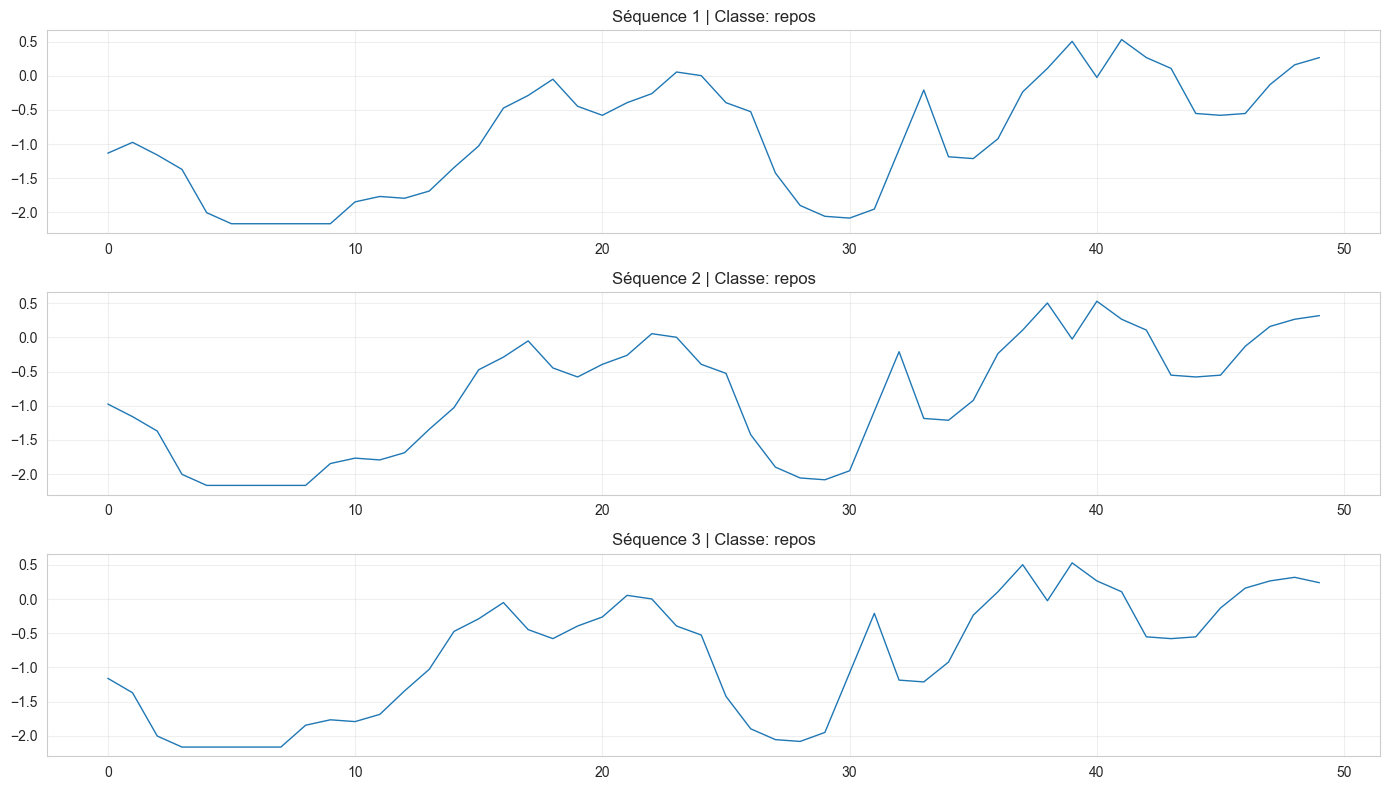

In [10]:
BASE_SEQUENCE_LENGTH = 50

rr_matrix = load_rr_matrix(
    CONFIG["mat_file_path"],
    CONFIG["mat_variable"]
)

X_base, y_base, meta_base = build_sequences(
    rr_matrix=rr_matrix,
    selected_columns=CONFIG["selected_columns"],
    sequence_length=BASE_SEQUENCE_LENGTH,
    stride=CONFIG["stride"],
    clip_quantiles=CONFIG["clip_quantiles"]
)

print("\nRésumé du dataset de base")
print(f"X_base: {X_base.shape}")
print(f"y_base: {y_base.shape}")

class_counts = pd.Series(y_base).value_counts().sort_index()
display(pd.DataFrame({
    "class_id": class_counts.index,
    "class_name": [CLASS_NAMES[i] for i in class_counts.index],
    "count": class_counts.values
}))

display(meta_base.head())

fig, axes = plt.subplots(3, 1, figsize=(14, 8))
for i in range(min(3, len(X_base))):
    axes[i].plot(X_base[i].squeeze(), linewidth=1)
    axes[i].set_title(f"Séquence {i+1} | Classe: {CLASS_NAMES[y_base[i]]}")
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Split train / validation / test

### Stratégies disponibles
- **random** : split stratifié classique
- **group** : split inter-individu, recommandé ici pour évaluer la généralisation physiologique

In [11]:
def split_train_val_test(X, y, groups, method="group", test_size=0.2, val_size=0.2, random_state=42):
    indices = np.arange(len(y))

    if method == "random":
        train_val_idx, test_idx = train_test_split(
            indices,
            test_size=test_size,
            random_state=random_state,
            stratify=y
        )

        val_relative = val_size / (1 - test_size)
        train_idx, val_idx = train_test_split(
            train_val_idx,
            test_size=val_relative,
            random_state=random_state,
            stratify=y[train_val_idx]
        )

    elif method == "group":
        gss_test = GroupShuffleSplit(
            n_splits=1,
            test_size=test_size,
            random_state=random_state
        )
        train_val_sub_idx, test_idx = next(gss_test.split(indices, y, groups))
        train_val_idx = indices[train_val_sub_idx]

        val_relative = val_size / (1 - test_size)
        gss_val = GroupShuffleSplit(
            n_splits=1,
            test_size=val_relative,
            random_state=random_state
        )
        train_sub_idx, val_sub_idx = next(
            gss_val.split(train_val_idx, y[train_val_idx], groups[train_val_idx])
        )
        train_idx = train_val_idx[train_sub_idx]
        val_idx = train_val_idx[val_sub_idx]

    else:
        raise ValueError("method doit valoir 'random' ou 'group'")

    return train_idx, val_idx, test_idx


def summarize_split(y, metadata, train_idx, val_idx, test_idx):
    rows = []
    for split_name, idx in [("train", train_idx), ("val", val_idx), ("test", test_idx)]:
        split_counts = pd.Series(y[idx]).value_counts().sort_index()
        for class_id in range(NUM_CLASSES):
            rows.append({
                "split": split_name,
                "class_id": class_id,
                "class_name": CLASS_NAMES[class_id],
                "count": int(split_counts.get(class_id, 0))
            })
    summary_df = pd.DataFrame(rows)

    print(summary_df.pivot(index="class_name", columns="split", values="count").fillna(0).astype(int))

    if metadata is not None and "subject_id" in metadata.columns:
        for split_name, idx in [("train", train_idx), ("val", val_idx), ("test", test_idx)]:
            print(f"{split_name}: {metadata.iloc[idx]['subject_id'].nunique()} sujets")


def compute_class_weights(y, num_classes):
    counts = np.bincount(y, minlength=num_classes)
    return {
        i: float(len(y)) / (num_classes * counts[i])
        for i in range(num_classes)
        if counts[i] > 0
    }


def prepare_split_bundle(X, y, metadata, split_method, test_size, val_size, random_state):
    groups = metadata["subject_id"].to_numpy()
    train_idx, val_idx, test_idx = split_train_val_test(
        X=X,
        y=y,
        groups=groups,
        method=split_method,
        test_size=test_size,
        val_size=val_size,
        random_state=random_state
    )

    summarize_split(y, metadata, train_idx, val_idx, test_idx)

    bundle = {
        "train_idx": train_idx,
        "val_idx": val_idx,
        "test_idx": test_idx,
        "X_train": X[train_idx],
        "X_val": X[val_idx],
        "X_test": X[test_idx],
        "y_train": y[train_idx],
        "y_val": y[val_idx],
        "y_test": y[test_idx],
        "meta_train": metadata.iloc[train_idx].reset_index(drop=True),
        "meta_val": metadata.iloc[val_idx].reset_index(drop=True),
        "meta_test": metadata.iloc[test_idx].reset_index(drop=True),
    }

    bundle["y_train_encoded"] = keras.utils.to_categorical(bundle["y_train"], NUM_CLASSES)
    bundle["y_val_encoded"] = keras.utils.to_categorical(bundle["y_val"], NUM_CLASSES)
    bundle["y_test_encoded"] = keras.utils.to_categorical(bundle["y_test"], NUM_CLASSES)
    bundle["class_weights"] = compute_class_weights(bundle["y_train"], NUM_CLASSES)

    return bundle

In [12]:
base_bundle = prepare_split_bundle(
    X=X_base,
    y=y_base,
    metadata=meta_base,
    split_method=CONFIG["split_method"],
    test_size=CONFIG["test_size"],
    val_size=CONFIG["val_size"],
    random_state=SEED
)

print("\nShapes")
print("X_train:", base_bundle["X_train"].shape)
print("X_val  :", base_bundle["X_val"].shape)
print("X_test :", base_bundle["X_test"].shape)
print("Class weights:", base_bundle["class_weights"])

split                         test  train   val
class_name                                     
coherence_cardiaque_immersif  2253   6757  2252
environnement_immersif        2284   6852  2284
repos                         2490   7469  2490
train: 36 sujets
val: 36 sujets
test: 36 sujets

Shapes
X_train: (21078, 50, 1)
X_val  : (7026, 50, 1)
X_test : (7027, 50, 1)
Class weights: {0: np.float64(0.9406881778015799), 1: np.float64(1.0253940455341506), 2: np.float64(1.0398105668195945)}


## 3. Définition du modèle et des configurations

Le modèle retenu est un **CNN-LSTM 1D** :
- CNN pour extraire les motifs locaux
- LSTM pour capturer la dynamique temporelle
- Dense final pour la classification multi-classe

In [13]:
def create_cnn_lstm_model(
    sequence_length,
    num_features,
    num_classes,
    filters=(32, 64),
    kernel_size=5,
    lstm_units=64,
    dense_units=32,
    dropout=0.3,
    learning_rate=1e-3,
):
    inputs = keras.Input(shape=(sequence_length, num_features))

    x = layers.Conv1D(filters[0], kernel_size=kernel_size, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(dropout)(x)

    x = layers.Conv1D(filters[1], kernel_size=kernel_size, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(dropout)(x)

    x = layers.LSTM(lstm_units, return_sequences=False)(x)
    x = layers.Dropout(dropout)(x)

    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

## Optimisation des hyperparamètres

In [14]:
SEARCH_SPACE = [
    {
        "sequence_length": 50,
        "filters": (32, 64),
        "kernel_size": 5,
        "lstm_units": 64,
        "dense_units": 32,
        "dropout": 0.30,
        "learning_rate": 1e-3,
        "batch_size": 64,
    },
    {
        "sequence_length": 75,
        "filters": (32, 64),
        "kernel_size": 5,
        "lstm_units": 64,
        "dense_units": 32,
        "dropout": 0.30,
        "learning_rate": 1e-3,
        "batch_size": 64,
    },
    {
        "sequence_length": 100,
        "filters": (32, 64),
        "kernel_size": 7,
        "lstm_units": 128,
        "dense_units": 64,
        "dropout": 0.40,
        "learning_rate": 5e-4,
        "batch_size": 64,
    },
]

search_results = []
best_score = -np.inf
best_params = None
best_bundle = None

for i, params in enumerate(SEARCH_SPACE, start=1):
    print(f"\n=== Configuration {i}/{len(SEARCH_SPACE)} ===")
    print(params)

    X_tmp, y_tmp, meta_tmp = build_sequences(
        rr_matrix=rr_matrix,
        selected_columns=CONFIG["selected_columns"],
        sequence_length=params["sequence_length"],
        stride=CONFIG["stride"],
        clip_quantiles=CONFIG["clip_quantiles"]
    )

    bundle = prepare_split_bundle(
        X=X_tmp,
        y=y_tmp,
        metadata=meta_tmp,
        split_method=CONFIG["split_method"],
        test_size=CONFIG["test_size"],
        val_size=CONFIG["val_size"],
        random_state=SEED
    )

    model = create_cnn_lstm_model(
        sequence_length=params["sequence_length"],
        num_features=1,
        num_classes=NUM_CLASSES,
        filters=params["filters"],
        kernel_size=params["kernel_size"],
        lstm_units=params["lstm_units"],
        dense_units=params["dense_units"],
        dropout=params["dropout"],
        learning_rate=params["learning_rate"],
    )

    callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=CONFIG["patience"],
            restore_best_weights=True,
            verbose=0
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-5,
            verbose=0
        )
    ]

    history = model.fit(
        bundle["X_train"],
        bundle["y_train_encoded"],
        validation_data=(bundle["X_val"], bundle["y_val_encoded"]),
        epochs=CONFIG["max_epochs"],
        batch_size=params["batch_size"],
        class_weight=bundle["class_weights"],
        callbacks=callbacks,
        verbose=0
    )

    y_val_proba = model.predict(bundle["X_val"], verbose=0)
    y_val_pred = np.argmax(y_val_proba, axis=1)

    val_accuracy = accuracy_score(bundle["y_val"], y_val_pred)
    val_f1 = f1_score(bundle["y_val"], y_val_pred, average="weighted")

    result_row = deepcopy(params)
    result_row.update({
        "val_accuracy": val_accuracy,
        "val_f1_weighted": val_f1,
        "epochs_trained": len(history.history["loss"]),
    })
    search_results.append(result_row)

    print(f"Validation accuracy: {val_accuracy:.4f}")
    print(f"Validation F1 weighted: {val_f1:.4f}")

    if val_f1 > best_score:
        best_score = val_f1
        best_params = deepcopy(params)
        best_bundle = bundle

search_df = pd.DataFrame(search_results).sort_values(
    by=["val_f1_weighted", "val_accuracy"],
    ascending=False
).reset_index(drop=True)

print("\nRésultats de recherche")
display(search_df)

print("\nMeilleure configuration")
print(best_params)


=== Configuration 1/3 ===
{'sequence_length': 50, 'filters': (32, 64), 'kernel_size': 5, 'lstm_units': 64, 'dense_units': 32, 'dropout': 0.3, 'learning_rate': 0.001, 'batch_size': 64}
Classe 'repos' | séries valides: 36 | fenêtres: 12449
Classe 'environnement_immersif' | séries valides: 36 | fenêtres: 11420
Classe 'coherence_cardiaque_immersif' | séries valides: 36 | fenêtres: 11262
split                         test  train   val
class_name                                     
coherence_cardiaque_immersif  2253   6757  2252
environnement_immersif        2284   6852  2284
repos                         2490   7469  2490
train: 36 sujets
val: 36 sujets
test: 36 sujets


KeyboardInterrupt: 

## Entrainement

In [ ]:
final_model = create_cnn_lstm_model(
    sequence_length=best_params["sequence_length"],
    num_features=1,
    num_classes=NUM_CLASSES,
    filters=best_params["filters"],
    kernel_size=best_params["kernel_size"],
    lstm_units=best_params["lstm_units"],
    dense_units=best_params["dense_units"],
    dropout=best_params["dropout"],
    learning_rate=best_params["learning_rate"],
)

final_model.summary()

final_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=CONFIG["patience"],
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5,
        verbose=1
    )
]

history = final_model.fit(
    best_bundle["X_train"],
    best_bundle["y_train_encoded"],
    validation_data=(best_bundle["X_val"], best_bundle["y_val_encoded"]),
    epochs=CONFIG["max_epochs"],
    batch_size=best_params["batch_size"],
    class_weight=best_bundle["class_weights"],
    callbacks=final_callbacks,
    verbose=1
)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 75, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 75, 32)         │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 75, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 37, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 37, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 37, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 37, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 18, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 18, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,083 (180.01 KB)

 Trainable params: 45,891 (179.26 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/30
299/299 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.6453 - loss: 0.6454 - val_accuracy: 0.5311 - val_loss: 0.9921 - learning_rate: 0.0010
Epoch 2/30
299/299 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7753 - loss: 0.4520 - val_accuracy: 0.6950 - val_loss: 0.6515 - learning_rate: 0.0010
Epoch 3/30
299/299 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8467 - loss: 0.3365 - val_accuracy: 0.7097 - val_loss: 0.7267 - learning_rate: 0.0010
Epoch 4/30
298/299 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8932 - loss: 0.2539
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
299/299 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9029 - loss: 0.2325 - val_accuracy: 0.7246 - val_loss: 0.8252 - learning_rate: 0.0010
Epoch 5/30
299/299 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9400 - loss: 0.1558 - val_accuracy: 0.7259 - val_loss: 0.9363 - learning_rate: 5.0000e-04
Epoch 6/30
297/299 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9520 - loss:

## Représentation visuelle de la performance du modèle

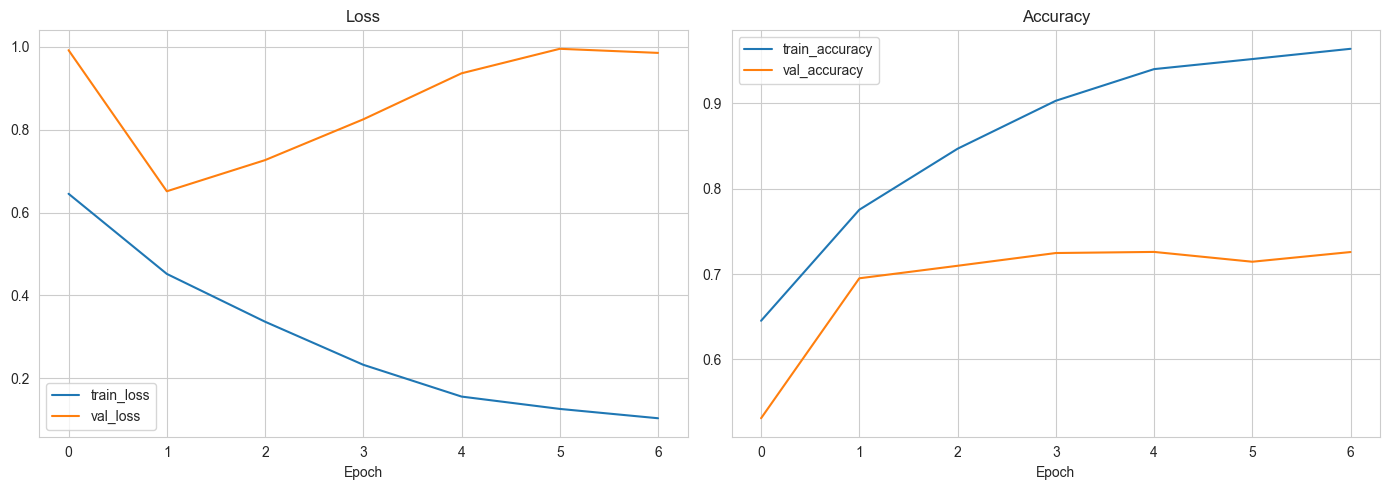

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["loss"], label="train_loss")
axes[0].plot(history.history["val_loss"], label="val_loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history["accuracy"], label="train_accuracy")
axes[1].plot(history.history["val_accuracy"], label="val_accuracy")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Evaluation standard et métriques appliquées au domaine physiologiques


MÉTRIQUES CLASSIQUES
Accuracy  : 0.6974
Precision : 0.6988
Recall    : 0.6974
F1-weight : 0.6884

RAPPORT DE CLASSIFICATION
                              precision    recall  f1-score   support

                       repos       0.62      0.42      0.50      2226
      environnement_immersif       0.54      0.69      0.60      2068
coherence_cardiaque_immersif       0.95      1.00      0.97      2097

                    accuracy                           0.70      6391
                   macro avg       0.70      0.70      0.69      6391
                weighted avg       0.70      0.70      0.69      6391



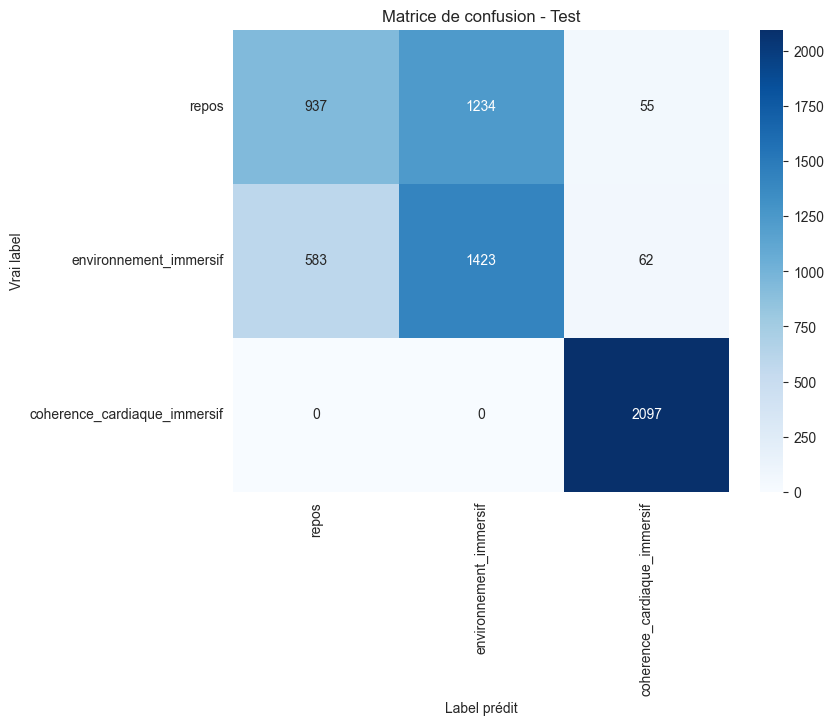


GÉNÉRALISATION INTER-INDIVIDU


,subject_id,n_samples,accuracy,f1_weighted
3,21,1041.0,0.786744,0.785674
6,31,792.0,0.744949,0.733769
1,13,909.0,0.720572,0.697488
5,30,821.0,0.712546,0.710293
7,35,742.0,0.669811,0.587883
4,26,608.0,0.644737,0.531224
2,16,636.0,0.635220,0.518947
0,12,842.0,0.611639,0.586609


Accuracy moyenne par sujet: 0.6908
Écart-type accuracy sujet : 0.0603

ROBUSTESSE / STABILITÉ
robust_accuracy_mean: 0.6964
robust_accuracy_std: 0.0030
prediction_stability_mean: 0.9758


In [ ]:
def evaluate_subject_generalization(y_true, y_pred, meta_test):
    df = meta_test.copy()
    df["y_true"] = y_true
    df["y_pred"] = y_pred

    subject_scores = (
        df.groupby("subject_id")
        .apply(lambda g: pd.Series({
            "n_samples": len(g),
            "accuracy": accuracy_score(g["y_true"], g["y_pred"]),
            "f1_weighted": f1_score(g["y_true"], g["y_pred"], average="weighted"),
        }))
        .reset_index()
    )
    return subject_scores


def evaluate_robustness(model, X, y, noise_std=0.05, repeats=5, seed=42):
    rng = np.random.default_rng(seed)
    base_pred = np.argmax(model.predict(X, verbose=0), axis=1)

    noisy_accuracies = []
    agreements = []

    for _ in range(repeats):
        noise = rng.normal(0, noise_std, size=X.shape).astype(np.float32)
        X_noisy = X + noise
        noisy_pred = np.argmax(model.predict(X_noisy, verbose=0), axis=1)

        noisy_accuracies.append(accuracy_score(y, noisy_pred))
        agreements.append((noisy_pred == base_pred).mean())

    return {
        "robust_accuracy_mean": float(np.mean(noisy_accuracies)),
        "robust_accuracy_std": float(np.std(noisy_accuracies)),
        "prediction_stability_mean": float(np.mean(agreements)),
    }


y_test_proba = final_model.predict(best_bundle["X_test"], verbose=0)
y_test_pred = np.argmax(y_test_proba, axis=1)

accuracy = accuracy_score(best_bundle["y_test"], y_test_pred)
precision = precision_score(best_bundle["y_test"], y_test_pred, average="weighted")
recall = recall_score(best_bundle["y_test"], y_test_pred, average="weighted")
f1 = f1_score(best_bundle["y_test"], y_test_pred, average="weighted")

print("\nMÉTRIQUES CLASSIQUES")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-weight : {f1:.4f}")

print("\nRAPPORT DE CLASSIFICATION")
print(classification_report(best_bundle["y_test"], y_test_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(best_bundle["y_test"], y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Matrice de confusion - Test")
plt.ylabel("Vrai label")
plt.xlabel("Label prédit")
plt.show()

subject_scores = evaluate_subject_generalization(
    best_bundle["y_test"],
    y_test_pred,
    best_bundle["meta_test"]
)

print("\nGÉNÉRALISATION INTER-INDIVIDU")
display(subject_scores.sort_values("accuracy", ascending=False))

print(f"Accuracy moyenne par sujet: {subject_scores['accuracy'].mean():.4f}")
print(f"Écart-type accuracy sujet : {subject_scores['accuracy'].std():.4f}")

robustness_metrics = evaluate_robustness(
    model=final_model,
    X=best_bundle["X_test"],
    y=best_bundle["y_test"],
    noise_std=CONFIG["noise_std_robustness"],
    repeats=CONFIG["noise_repeats"],
    seed=SEED
)

print("\nROBUSTESSE / STABILITÉ")
for k, v in robustness_metrics.items():
    print(f"{k}: {v:.4f}")

##  Analyse des patterns appris

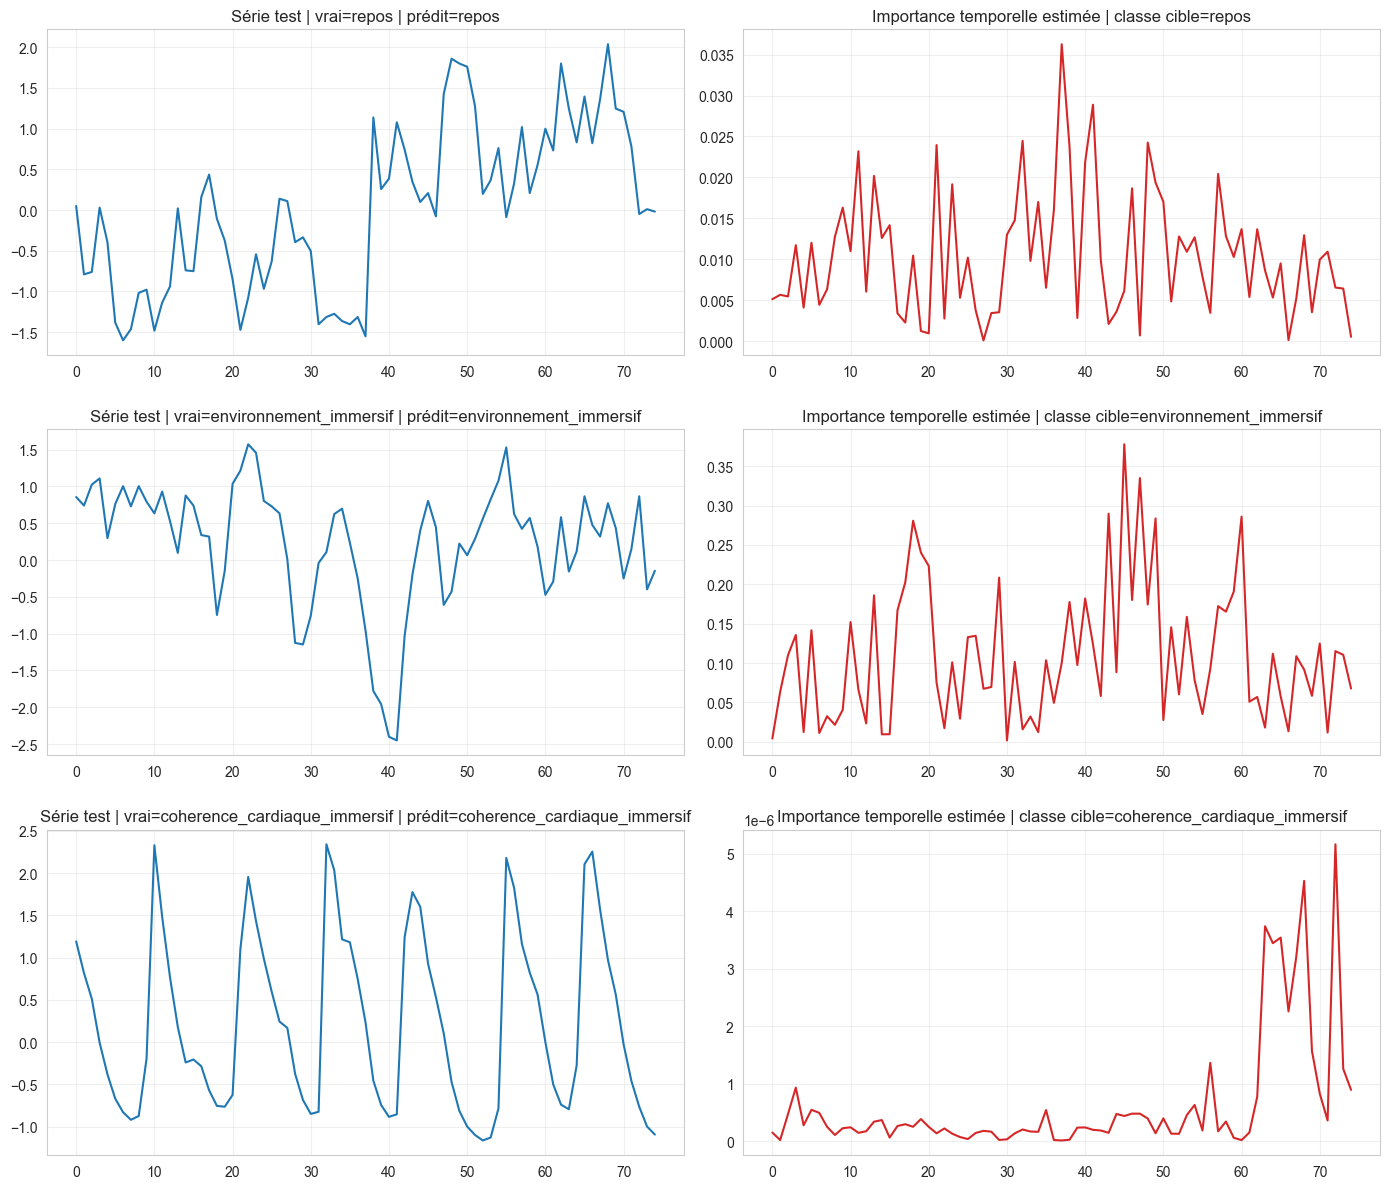

In [ ]:
def compute_saliency_map(model, sample, target_class=None):
    x = tf.convert_to_tensor(sample[np.newaxis, ...], dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(x)
        probs = model(x, training=False)

        if target_class is None:
            target_class = int(tf.argmax(probs[0]).numpy())

        target_score = probs[:, target_class]

    grads = tape.gradient(target_score, x)[0].numpy().squeeze()
    saliency = np.abs(grads)
    return saliency, target_class


fig, axes = plt.subplots(NUM_CLASSES, 2, figsize=(14, 4 * NUM_CLASSES))

for class_id in range(NUM_CLASSES):
    candidate_idx = np.where(best_bundle["y_test"] == class_id)[0]
    if len(candidate_idx) == 0:
        continue

    sample_idx = candidate_idx[0]
    sample = best_bundle["X_test"][sample_idx]
    true_label = best_bundle["y_test"][sample_idx]
    pred_label = y_test_pred[sample_idx]

    saliency, target_class = compute_saliency_map(final_model, sample, target_class=pred_label)

    axes[class_id, 0].plot(sample.squeeze(), color="tab:blue")
    axes[class_id, 0].set_title(
        f"Série test | vrai={CLASS_NAMES[true_label]} | prédit={CLASS_NAMES[pred_label]}"
    )
    axes[class_id, 0].grid(True, alpha=0.3)

    axes[class_id, 1].plot(saliency, color="tab:red")
    axes[class_id, 1].set_title(f"Importance temporelle estimée | classe cible={CLASS_NAMES[target_class]}")
    axes[class_id, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Synthèse automatique

In [ ]:
summary = {
    "objectif": "classification multi-classe des états expérimentaux à partir des RR intervals",
    "split_method": CONFIG["split_method"],
    "best_sequence_length": best_params["sequence_length"],
    "best_filters": best_params["filters"],
    "best_kernel_size": best_params["kernel_size"],
    "best_lstm_units": best_params["lstm_units"],
    "best_dropout": best_params["dropout"],
    "test_accuracy": accuracy,
    "test_f1_weighted": f1,
    "mean_subject_accuracy": float(subject_scores["accuracy"].mean()),
    "std_subject_accuracy": float(subject_scores["accuracy"].std()),
    **robustness_metrics
}

summary_df = pd.DataFrame([summary]).T.rename(columns={0: "value"})
display(summary_df)

,value
objectif,classification multi-classe des états expérime...
split_method,group
best_sequence_length,75
best_filters,"(32, 64)"
best_kernel_size,5
best_lstm_units,64
best_dropout,0.3
test_accuracy,0.697387
test_f1_weighted,0.688358
mean_subject_accuracy,0.690777


: 

## Interprétation attendue

- La performance globale doit être lue avec les métriques classiques (accuracy, F1 weight).
- La généralisation inter-individu est analysée via les scores par sujet.
- La robustesse est estimée par perturbation bruitée des séquences de test.
- L’analyse des patterns appris repose ici sur une carte de saillance temporelle.